# The PID controller

Proportional-Integral-Derivative (PID) control is a standard method of process control.


<img src = "./model.svg" width=150px>

## Model Equations

The change in the manipulated variable caused by the PID controller is made up of the proportional, integral and differential components

$$y(t) = {K_c}\left[ {e(t) + \frac{1}{{{T_I}}}\int\limits_0^t {e(\tau)d\tau}  + {T_D}\frac{{d(e(t))}}{{dt}}} \right]$$

with:

$T_I$ = reset time of the I controller element

$T_D$ = lead time of the D control element

$K_c$ = Reinforcement

$e$ = error, difference between setpoint and process value

$y$ = change in manipulated variable


The practical implementation of PID control is generally achieved through a number of modifications.

### Independent parameters

It is common to introduce an independent parameterization for each of the terms P, I, and D. By transformation one obtains:

$$y(t) = k_P(e(t)) + k_I\int\limits_0^t e(\tau)d\tau + k_D\frac{d(e(t))}{dt}$$

with:

\begin{align*}
k_P & = K_c \\
k_I & = \frac{K_c}{T_I} \\
k_D & = K_c T_D
\end{align*}

### Setpoint weighting

If the PID control is implemented directly in standard form, then step changes in the setpoint $T_{sp}$ can lead to undesired behavior. It is therefore common to introduce setpoint weighting factors for the proportional and derivative terms. This leads to the following equation:

$$y(t) = k_P(e_P(t)) + k_I\int\limits_0^t e_I(\tau)d\tau + k_D\frac{d(e_D(t))}{dt}$$

with:

\begin{align*}
e_P(t) & = \beta x_{sp}(t) - x(t) \\
e_I(t) & = x_{sp}(t) - x(t) \\
e_D(t) & = \gamma x_{sp}(t) - x(t)
\end{align*}

where $x_{sp}(t)$ is the target value of the measured variable (which can also vary over time) and $x(t)$ is the process value.

It is common to set $\gamma = 0$, which eliminates the derivative effect due to a change in setpoint. This function is sometimes called "derivative on output". This is common in process control because it avoids the strong controller response (also known as "derivative kick") associated with a change in setpoint.

In practice, the term $\beta$ is generally tuned to specific application needs. In this case, where setpoint tracking is not a high priority, setting $\beta = 0$ is a good starting point.

### Discrete-time implementation

The simulation strategy used here requires a time-discrete implementation of the PID controller. For a sample time $\Delta t$ the PID algorithm becomes:

$$y(t_k) = k_P (e_P(t_k)) + k_I\sum_{n=1}^{k} e_I(t_{n}) \Delta t + k_D\frac{e_D(t_k)-e_D(t_ {k-1})}{\Delta t}$$

The implementation is further optimized by setting up the difference equation for $y(t_k)$ - $y(t_{k-1})$ for the changes:

$$\Delta y(t_k) = y(t_k) - y(t_{k-1})$$

The iterative method is obtained by insertion and transformation:

$$\Delta y(t_k) = k_P \left[e_P(t_k)-e_P(t_{k-1})\right] + k_I e_I(t_k)\Delta t + k_D\frac{e_D(t_k) - 2e_D (t_{k-1}) + e_D(t_{k-2})}{\Delta t}$$


### Control limitation

Furthermore, it must be taken into account that in practice the coolant flow is fixed at a lower and upper limit. This is achieved by the following saturation equation:

$$Y(t_k) = \max \left[ Y_{min}, \min(Y_{max}, Y(t_{k-1}) + \Delta y(t_k))\right]$$

## Application using the example of an exothermic reaction in a stirred tank.

### Implementation of the  test case

In [2]:
Ea  = 72750.0  # Activation energy [J/mol]
R   = 8.314    # Gas constant [J/mol/K]
k0  = 7.2e10   # Arrhenius rate constant [1/min]
V   = 100.0    # Volume [l]
rho = 1000.0   # Density [g/l]
Cp  = 0.239    # Heat capacity [J/g/K]
dHr = -5.0e4   # Enthalpy of reaction [J/mol]
UA  = 5.0e4    # Heat transfer [J/min/K]
q   = 100.0    # Flowrate [l/min]
cAf = 1.0      # Inlet feed concentration [mol/l]
Trf  = 300.0   # Inlet feed temperature [K]
cA0 = 0.5      # Initial concentration [mol/l]
Tr0  = 350.0;  # Initial temperature [K]
Tcf = 300.0    # Coolant feed temperature [K]
qc  = 50.0     # Nominal coolant flowrate [l/min]
Vc  = 20.0     # Cooling jacket volume [l]

def cstr(z, t, theta):
    # State variables
    cA, Tr, Tc = z
    # Parameters
    qc = theta
    
    # Arrhenius rate expression
    k = k0*np.exp(-Ea/R/Tr)
    
    # Differential equations
    dcA = (q/V)*(cAf-cA) - k*cA
    dTr = (q/V)*(Trf-Tr) + (-dHr/rho/Cp)*k*cA + (UA/V/rho/Cp)*(Tc-Tr)
    dTc = (qc/Vc)*(Tcf-Tc) + (UA/Vc/rho/Cp)*(Tr-Tc)
    
    return [dcA, dTr, dTc]

### Implementation of the result visualization

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_result(t_frame, c_A, T_r, T_c, q_c, T_sp):
    # Create matplotlib figure and axis
    fig = plt.figure(figsize=(9, 5))  

    # Add grid spec
    gs = fig.add_gridspec(5, 1)

    # Draw 10 markers on every line plot
    points = int(len(t_frame)/10)

    # Create a subplot in the top of the figure
    ax_top = plt.subplot(gs[0:2, 0])

    # Plot cool medium flow rate
    line0 = ax_top.plot(t_frame, q_c, "C3-D", label="$q_c$", markevery=points)

    # Set axis label
    ax_top.set_ylabel("Cooling flow rate [l/min]")

    # Add legend to the top subplot
    ax_top.legend(loc=1)

    # Tune axis (show grid and remove x-labels)
    ax_top.grid()
    for xlabel_i in ax_top.axes.get_xticklabels():
        xlabel_i.set_visible(False)
        xlabel_i.set_fontsize(0.0)

    # Create a subplot at the bottom of the figure
    # share x axis with the top subplot
    ax_bottom = plt.subplot(gs[2:5, 0], sharex = ax_top)

    # Plot recator temperature set point
    line1 = ax_bottom.plot(t_frame, T_sp,'C3', label="$T_{r, set}$")

    # Plot inner reactor temperature
    line2 = ax_bottom.plot(t_frame , T_r, "C0-D", label="$T_r$", markevery=points)

    # Plot reactor cooling jacket temperature
    line3 = ax_bottom.plot(t_frame , T_c, "C1-o", label="$T_c$", markevery=points)

    # Set axis labels
    ax_bottom.set_ylabel("Temperature [K]")
    ax_bottom.set_xlabel("Time [min]")

    # Tune axis 
    ax_bottom.grid()
    ax_bottom.xaxis.set_major_locator(ticker.AutoLocator())
    ax_bottom.xaxis.set_minor_locator(ticker.AutoMinorLocator())   

    # Create a second y-axes in the bottom subplot that shares the x-axis 
    ax_bottom_twin = ax_bottom.twinx()  

    # Plot concentration of component A
    line4 = ax_bottom_twin.plot(t_frame, c_A, "C2-s", label="$c_A$", markevery=points)

    # Set axis label
    ax_bottom_twin.set_ylabel("Concentration [mol/l]")

    # Create legend
    lines = line1 + line2 + line3 + line4
    labels = [line.get_label() for line in lines]
    ax_bottom_twin.legend(lines, labels, loc=1)        

    #  Show plot
    plt.tight_layout()
    plt.show()


### Computation and result of the uncontrolled test case

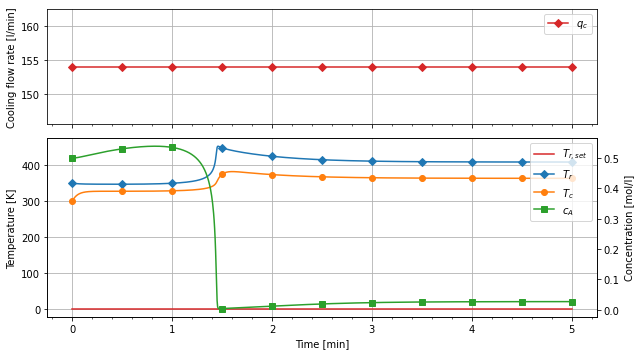

In [10]:
from scipy.integrate import odeint
import numpy as np

# ODE solver parameter
abserr = 1.0e-8
relerr = 1.0e-6

# Setup integration time
t_start = 0.0
t_end = 5.0
numpoints = 1001
t = np.linspace(t_start, t_end, numpoints)

y_sol = odeint(
    cstr, [cA0, Tr0, Tcf], t, args=(150.0,), 
    atol=abserr, rtol=relerr)
cA = y_sol[:,0]
Tr = y_sol[:,1]
Tc = y_sol[:,2]

plot_result(t, cA, Tr, Tc, np.full(numpoints, qc), np.zeros(numpoints))

The reaction $A \xrightarrow{k \cdot c_A}{} \text{product}$ is obviously strongly exothermic.

If the reactor is operated without cooling, it will reach an operating temperature of over 450 K, leading to significant pressurization, a potentially dangerous condition and possible product degradation.

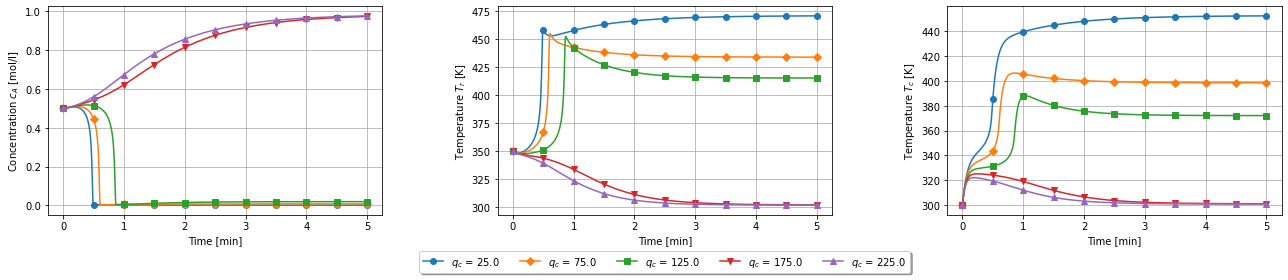

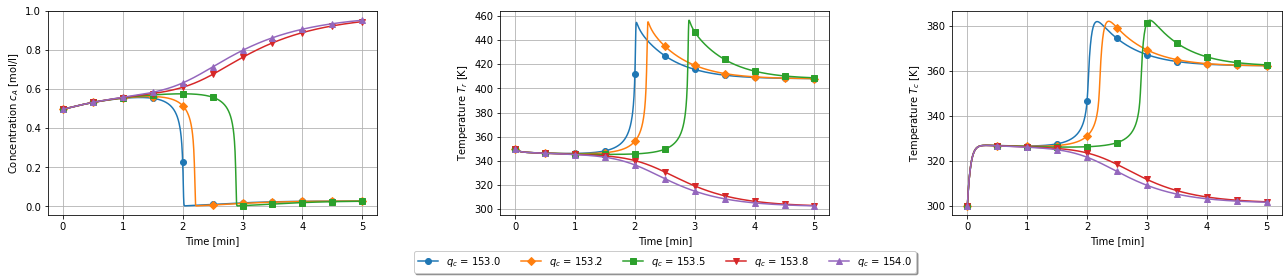

In [12]:
import matplotlib.pyplot as plt

# Visualization plots concentration and temperature on given axes
def plot_solution(ax, t, cA, Tr, Tc, marker, legend_x_pos = 0.5):
    points = int(t.size/10)
    ax[0].plot(t, cA, '-', label="$q_c$ = {:.1f}".format(qc), marker=marker, markevery=points)
    ax[0].set_xlabel('Time [min]')
    ax[0].set_ylabel('Concentration $c_A$ [mol/l]')
    ax[0].grid(True)
    
    ax[1].plot(t, Tr,'-', label="$q_c$ = {:.1f}".format(qc), marker=marker, markevery=points)
    ax[1].set_xlabel('Time [min]')
    ax[1].set_ylabel('Temperature $T_r$ [K]');
    ax[1].grid(True) 
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=8)    

    ax[2].plot(t, Tc,'-', label="$q_c$ = {:.1f}".format(qc), marker=marker, markevery=points)
    ax[2].set_xlabel('Time [min]')
    ax[2].set_ylabel('Temperature $T_c$ [K]');
    ax[2].grid(True) 
    plt.tight_layout()
    
# Iterate over flowrates qc
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
markers=["o", "D", "s", "v", "^"]
index = 0
for qc in np.linspace(25,225,5):
    z = odeint(cstr, [cA0, Tr0, Tcf], t, args=(qc,), atol=abserr, rtol=relerr)
    plot_solution(ax, t, z[:,0], z[:,1], z[:,2], markers[index]);
    index +=1

fig, ax = plt.subplots(1, 3, figsize=(18, 4))  
index = 0
for qc in np.linspace(153,154,5):
    z = odeint(cstr, [cA0, Tr0, Tcf], t, args=(qc,), atol=abserr, rtol=relerr)
    plot_solution(ax, t, z[:,0], z[:,1], z[:,2], markers[index]);
    index +=1
    

The condition of the reactor depends very much on the coolant flow. A coolant flow rate of less than 150 L/min results in a steady state with high conversion greater than 95% and a reactor temperature greater than about 410 K. Coolant flow rates greater than 155 L/min result in inefficient operation with low conversion .

The aim of the control is now to achieve stable operation of the reactor at a steady state with a high conversion rate but an operating temperature below 400 K. This is an operating condition that is hardly possible without feedback control.


### Control with PID controller

The following equation results from the specific example of flow control:

$$\Delta q_c(t) = K_c\left[(T_{sp}(t) - T(t)) + \frac{1}{T_I}\int\limits_0^t (T_{sp}(\tau ) - T(\tau))d\tau + T_D\frac{d(T_{sp}(t) - T(t))}{dt} \right]$$

$$=>$$

$$q(t_k) = q(t_{k-1}) + \left[k_P \left[e_P(t_k)-e_P(t_{k-1})\right] + k_I e_I(t_k)\Delta t + k_D\frac{e_D(t_k) - 2e_D(t_{k-1}) + e_D(t_{k-2})}{\Delta t}\right]$$

With

\begin{align*}
e_P(t) & = \beta T_{sp}(t) - T(t) \\
e_I(t) & = T_{sp}(t) - T(t) \\
e_D(t) & = \gamma T_{sp}(t) - T(t)
\end{align*}

For control reactor temperature, note that the controller "acts directly" so that a positive increase in reactor temperature $T$ above the $T_{sp}$set point is offset by an increase in coolant flow, and vice versa.

## Implementation of the controller model


In [ ]:
from simunetcore import Model
import numpy as np

# Model implementation for the Tank
class PIDController(Model):
    def __init__(self, name=""):
        Model.__init__(self, name)

        # Model Parameters
        self.params = {
            "y_range": {
                "value": [4.0, 20.0],
                "description": "Range of controller output",
                "unit": "-",
            },
            "k_p": {
                "value": 12,
                "description": "Proportional control gain",
                "unit": "-",
            },
            "k_i": {
                "value": 0.9, 
                "description": "Integral control gain", 
                "unit": "-"
            },
            "k_d": {
                "value": 20.0,
                "description": "Derivative control gain",
                "unit": "-",
            },
            "beta": {
                "value": 1.0,
                "description": "Setpoint weighting for proportional control",
                "unit": "-",
            },
            "gamma": {
                "value": 1.0,
                "description": "Setpoint weighting for derivative control",
                "unit": "-",
            },
            "mode": {
                "value": "direct",
                "description": "Mode of operation (direct, inverse)",
                "unit": "-",
                "property": {
                    "editor": "option",
                    "options": ["direct", "inverse"]
                }
            },
            "delta_t" : {
                "value": 0.0, 
                "description": "Time intervall", 
                "unit": "s"
            }
        }
        # Model variables
        self.vars = {
            "p_v": {"description": "Process value", "unit": "mA"},
            "m_v": {"description": "Manipulated value", "unit": "mA"},
            "s_p": {"description": "Set Point", "unit": "mA"},
        }
        # Model inputs
        self.u = {
            "u_1": {
                "type": "signal",
                "description": "Instrument input",
                "vars": ["p_v"],
            },
            "u_2": {
                "type": "signal",
                "description": "Set Point input",
                "vars": ["s_p"],
            },
        }
        # Model outputs
        self.y = {
            "y_1": {
                "type": "control",
                "description": "Controller output",
                "vars": ["m_v"],
            }
        }
        self.__eP = None
        self.__eP1 = None
        self.__eI = None
        self.__eD = None
        self.__eD1 = None
        self.__eD2 = None
        self.__t_last = 0

    def reset(self):
        self.__eP = None
        self.__eP1 = None
        self.__eI = None
        self.__eD = None
        self.__eD1 = None
        self.__eD2 = None

    def compute(self, *args, **kwargs):
        # Parameter
        y_min, y_max = self.get_param("y_range")
        k_p = self.get_param("k_p")
        k_i = self.get_param("k_i")
        k_d = self.get_param("k_d")
        beta = self.get_param("beta")
        gamma = self.get_param("gamma")
        if self.get_param("mode") == "direct":
            mode = 1.0
        elif self.get_param("mode") == "inverse":
            mode = -1.0
        else:
            raise AttributeError("mode")


        delta_t = self.get_param("delta_t")
        t_frame = self.get_t()

        # Create python list to log results
        result = []

        # Get inital values set point, process value and  manipulated value
        s_p = self.get_var("s_p", t_frame[0])
        p_v = self.get_var("p_v", t_frame[0])
        m_v = self.get_var("m_v")[-1]

        # Set the inital errors in the first run
        if self.__eP1 is None:
            self.__eP1 = beta * s_p - p_v
        if self.__eD1 is None:
            self.__eD1 = gamma * s_p - p_v
        if self.__eD2 is None:
            self.__eD2 = gamma * s_p - p_v

        # Compute dt (assume equidistant stepsize)
        if delta_t == 0:
            dt = (t_frame[-1] - t_frame[0]) / (len(t_frame) - 1)
        else:
            dt = delta_t

        for i in range(len(t_frame)):
            # Append current manipulated to the result
            result.append(m_v)

            # Get time step
            t = t_frame[i]

            # Evaluate only after time intervall (delta_t)
            if t >= self.__t_last + delta_t or delta_t == 0:
                # Get set point and processvalue for the time step
                s_p = self.get_var("s_p", t)
                p_v = self.get_var("p_v", t)

                # Error calculations
                self.__eP = beta * s_p - p_v
                self.__eI = s_p - p_v
                self.__eD = gamma * s_p - p_v

                # PID control calculations
                dy = k_p * (self.__eP - self.__eP1)
                dy += k_i * dt * self.__eI
                dy += k_d * (self.__eD - 2 * self.__eD1 + self.__eD2) / dt

                # Update and saturatemanipulatedd value
                m_v -= mode * dy
                m_v = max(y_min, min(y_max, m_v))

                # Save data for the next iteration
                self.__eD2 = self.__eD1
                self.__eD1 = self.__eD
                self.__eP1 = self.__eP
                
                # Increment __t_last    
                self.__t_last += dt

        # Return result array
        self.set_var("m_v", result)

## Computation of the controlled test case

In [17]:
# Create model
M_6 = PIDController("M_6")

#cSet parameters
M_6.set_param("mode", 1) 
M_6.set_param("y_range", [0.0, 350.0]) 
M_6.set_param("k_p", 40.0) 
M_6.set_param("k_i", 80.0) 
M_6.set_param("k_d", 0) 
M_6.set_param("beta", 0) 
M_6.set_param("gamma", 0) 

# Setpoint
Tsp=385.0
M_6.set_var("s_p", Tsp)

# Do simulation at fixed time steps dt from t_start
t_start = 0.0
t_end = 8.0
dt = 0.005

# Create python list to log results
result = []

# Set initial conditions and initial cooling flow
cA, Tr, Tc = cA0, Tr0, Tcf
qc = 150

for t in np.linspace(t_start, t_end, int((t_end-t_start)/dt)+1):
    # Switch set pooint at t=4 min
    if t == 4:
        Tsp= 400
        
    # log data and update state
    result.append([t, cA, Tr, Tc, qc, Tsp])
               
    # Start at t, find state at t + dt
    cA, Tr, Tc = odeint(
        cstr, [cA, Tr, Tc], [t,t+dt], args=(qc,), 
        atol=abserr, rtol=relerr)[-1]

    # Set initial values
    M_6.set_var("s_p", [Tsp, Tsp])
    M_6.set_var("p_v", [Tr, Tr])
    M_6.set_var("m_v", [qc])
    
    # Solve model
    M_6.set_t([t, t+dt])
    M_6.compute()
    
    # Setup inital values
    qc = M_6.get_var("m_v")[-1]

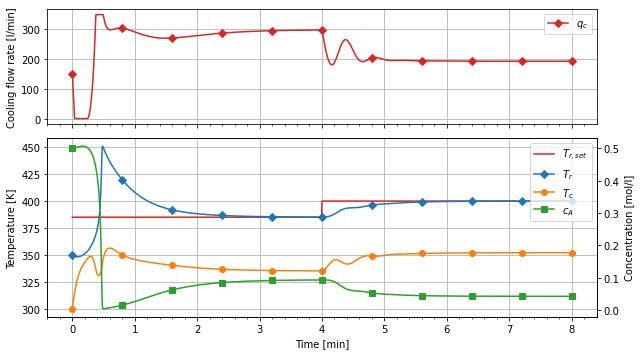

In [18]:
t, cA, Tr, Tc, qc, Tsp = np.asarray(result).T
plot_result(t, cA, Tr, Tc, qc, Tsp)